# 01 — Exploratory Data Analysis : Open Food Facts → Nutri-Score

**Objectif** : comprendre la structure des données, quantifier les problèmes de qualité
et produire les décisions de préprocessing qui guideront `src/preprocessing.py`.

**Rappel anti-fuite** : `nutrition-score-fr_100g` et `nutrition-score-uk_100g` sont
directement calculés à partir du Nutri-Score — ils ne doivent **jamais** apparaître
parmi les features. Idem pour toute colonne contenant `nutriscore` ou `nutrition-score`.

In [1]:
import sys, warnings
from pathlib import Path

# Ce travail est executable depuis n'importe quel répertoire du projet, et même depuis un notebook.
_project = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src").is_dir()),
    Path.cwd().resolve(),
)
if str(_project) not in sys.path:
    sys.path.insert(0, str(_project))

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.config import (
    RAW_DIR, PROCESSED_DIR, RANDOM_STATE,
    SAMPLE_SIZE, TARGET, NUTRITIONAL_FEATURES,
    CATEGORICAL_FEATURES, USECOLS
)
from src.utils import load_off

FIGURES = 'figures/'
import os; os.makedirs(FIGURES, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Chargement de l'échantillon

On ne charge que les colonnes utiles (`USECOLS` de `config.py`) pour éviter de saturer
la RAM avec les ~200 colonnes du dump complet.
L'argument `nrows=SAMPLE_SIZE` limite à 80 000 lignes pour l'exploration.

In [2]:
RAW_PATH = RAW_DIR / 'en.openfoodfacts.org.products.csv'

df_raw = load_off(RAW_PATH, usecols=USECOLS, nrows=SAMPLE_SIZE)
print(f'Colonnes chargées  : {list(df_raw.columns)}')
print(f'Shape              : {df_raw.shape}')

Colonnes chargées  : ['nutrition_grade_fr', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']
Shape              : (80000, 9)


## 2. Vue d'ensemble : shape, types, aperçu

In [3]:
df_raw.head(3)

,nutrition_grade_fr,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d,2243.0,28.57,28.57,64.29,14.29,3.6,3.57,0.000
2,b,1941.0,17.86,0.00,60.71,17.86,7.1,17.86,0.635


In [4]:
df_raw.dtypes.to_frame('dtype')

,dtype
nutrition_grade_fr,str
energy_100g,float64
fat_100g,float64
saturated-fat_100g,float64
carbohydrates_100g,float64
sugars_100g,float64
fiber_100g,float64
proteins_100g,float64
salt_100g,float64


### 2.1 Valeurs manquantes par colonne

Toutes les variables nutritionnelles sont numériques mais saisies manuellement par les
fabricants → fort taux de NaN attendu. La cible `nutrition_grade_fr` peut aussi être
absente pour les produits sans calcul Nutri-Score.

,missing_%,n_missing
fiber_100g,23.0,18410
nutrition_grade_fr,22.6,18093
saturated-fat_100g,19.0,15233
sugars_100g,9.8,7822
fat_100g,3.4,2744
carbohydrates_100g,3.4,2711
proteins_100g,3.3,2647
salt_100g,3.3,2667
energy_100g,3.1,2470


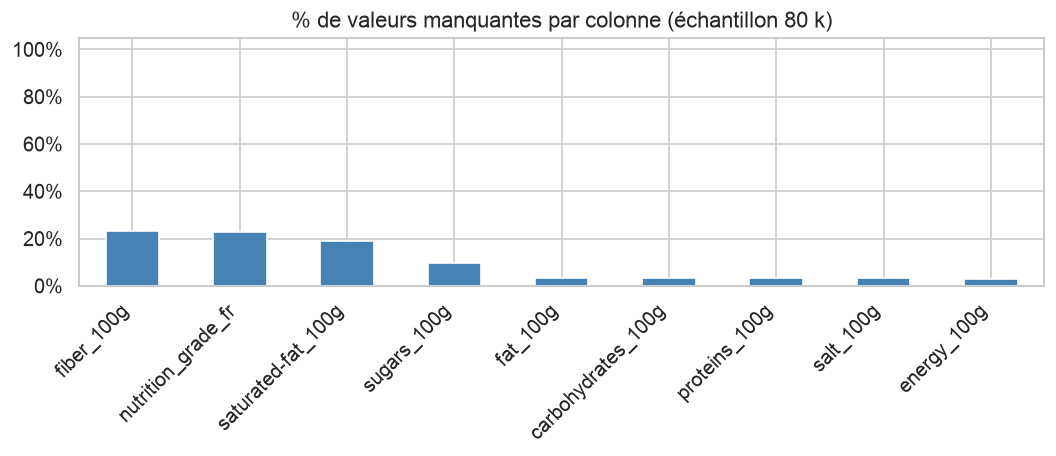

In [5]:
missing = (
    df_raw.isna()
    .mean()
    .mul(100)
    .rename('missing_%')
    .round(1)
    .sort_values(ascending=False)
    .to_frame()
)
missing['n_missing'] = df_raw.isna().sum().values[missing.index.map(lambda c: list(df_raw.columns).index(c))]

# recalcul propre
missing = pd.DataFrame({
    'missing_%': df_raw.isna().mean().mul(100).round(1),
    'n_missing':  df_raw.isna().sum()
}).sort_values('missing_%', ascending=False)

display(missing)

fig, ax = plt.subplots(figsize=(9, 4))
missing['missing_%'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('% de valeurs manquantes par colonne (échantillon 80 k)')
ax.set_xlabel('')
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES + 'missing_values.png')
plt.show()

## 3. Distribution de la cible `nutrition_grade_fr`

Le Nutri-Score est une classification ordinale A (meilleur) → E (moins bon).
On s'attend à un déséquilibre marqué : certaines classes (souvent B et D) sont
sur-représentées selon la composition du catalogue Open Food Facts.

Distribution de la cible :


,count,proportion_%
nutrition_grade_fr,,
a,10361,16.7
b,9923,16.0
c,12085,19.5
d,17715,28.6
e,11823,19.1


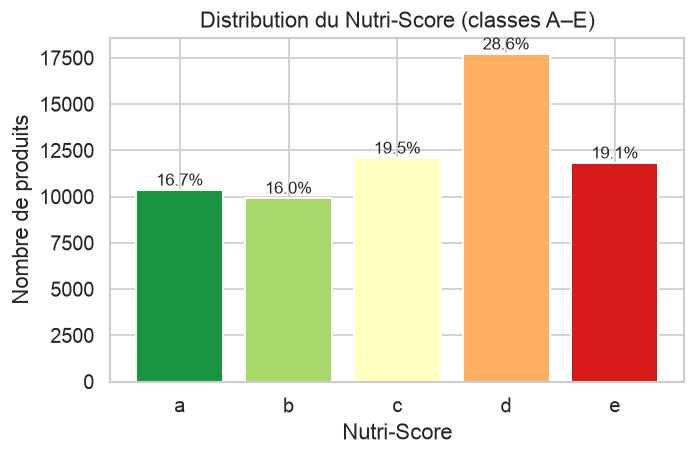

In [6]:
# On normalise les valeurs : minuscules, strip
df = df_raw.copy()
df[TARGET] = df[TARGET].str.strip().str.lower()

grade_order = ['a', 'b', 'c', 'd', 'e']
colors = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

target_counts  = df[TARGET].value_counts().reindex(grade_order).fillna(0).astype(int)
target_pct     = target_counts / target_counts.sum() * 100

summary_target = pd.DataFrame({'count': target_counts, 'proportion_%': target_pct.round(1)})
print('Distribution de la cible :')
display(summary_target)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(grade_order, target_counts, color=colors, edgecolor='white', linewidth=1.2)
for bar, pct in zip(bars, target_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Distribution du Nutri-Score (classes A–E)')
ax.set_xlabel('Nutri-Score')
ax.set_ylabel('Nombre de produits')
plt.tight_layout()
plt.savefig(FIGURES + 'target_distribution.png')
plt.show()

> **Observation** : Le déséquilibre visible justifiera l'usage de `class_weight='balanced'`
> (sklearn) ou de métriques macro-moyennées (F1-macro, AUC-OvR) plutôt que l'accuracy brute.

## 4. Distributions des variables nutritionnelles

On commence par convertir toutes les colonnes numériques, puis on trace un histogramme
pour chaque nutriment. On superpose les seuils physiques :

| Variable | Borne min | Borne max raisonnable |
|---|---|---|
| energy_100g | 0 | 3 700 kJ (pur lipide) |
| fat_100g | 0 | 100 |
| saturated-fat_100g | 0 | fat_100g |
| carbohydrates_100g | 0 | 100 |
| sugars_100g | 0 | carbohydrates_100g |
| proteins_100g | 0 | 100 |
| salt_100g | 0 | 100 |
| sodium_100g | 0 | ~40 (sel = Na × 2.5) |
| fiber_100g | 0 | 100 |

Toute valeur négative ou dépassant la borne max est une **aberration à filtrer**.

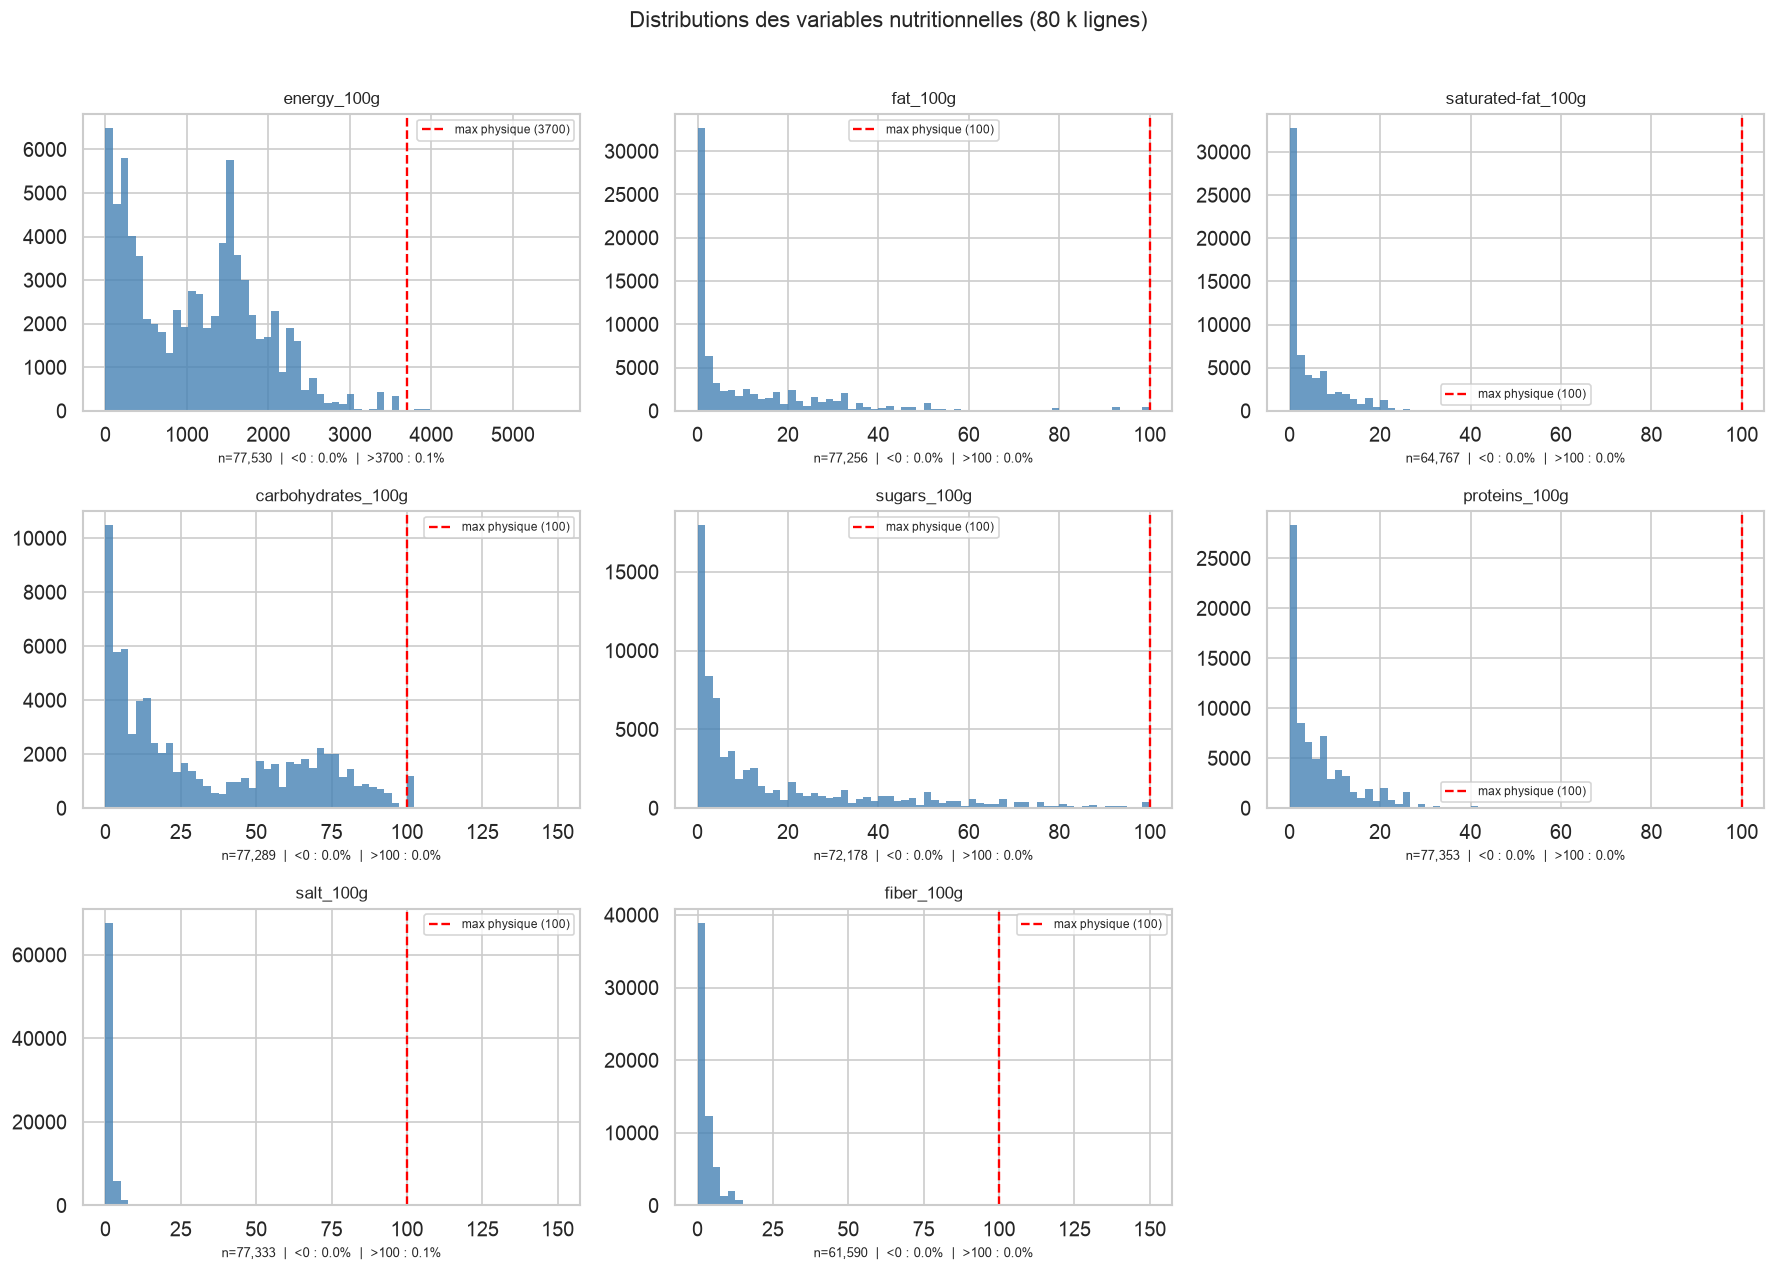

In [7]:
# Conversion numérique
for col in NUTRITIONAL_FEATURES:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

PHYSICAL_BOUNDS = {
    'energy_100g':        (0, 3700),
    'fat_100g':           (0, 100),
    'saturated-fat_100g': (0, 100),
    'carbohydrates_100g': (0, 100),
    'sugars_100g':        (0, 100),
    'proteins_100g':      (0, 100),
    'salt_100g':          (0, 100),
    'sodium_100g':        (0, 40),
    'fiber_100g':         (0, 100),
}

num_features = [f for f in NUTRITIONAL_FEATURES if f in df.columns]
n = len(num_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    data = df[col].dropna()
    lo, hi = PHYSICAL_BOUNDS.get(col, (0, data.max()))

    n_neg    = (data < lo).sum()
    n_above  = (data > hi).sum()
    pct_neg  = n_neg  / len(data) * 100
    pct_abv  = n_above / len(data) * 100

    # clip pour la lisibilité
    data_clipped = data.clip(lo, hi * 1.5)
    ax.hist(data_clipped, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(hi, color='red', linestyle='--', linewidth=1.4, label=f'max physique ({hi})')
    if lo > 0:
        ax.axvline(lo, color='orange', linestyle='--', linewidth=1.4, label=f'min physique ({lo})')

    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    subtitle = f'n={len(data):,}  |  <0 : {pct_neg:.1f}%  |  >{hi} : {pct_abv:.1f}%'
    ax.set_xlabel(subtitle, fontsize=8)
    ax.legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions des variables nutritionnelles (80 k lignes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + 'nutritional_distributions.png', bbox_inches='tight')
plt.show()

In [8]:
# Tableau de synthèse des aberrations
anomaly_rows = []
for col in num_features:
    lo, hi = PHYSICAL_BOUNDS.get(col, (0, None))
    data = df[col].dropna()
    n_neg   = int((data < lo).sum())
    n_above = int((data > hi).sum()) if hi is not None else 0
    anomaly_rows.append({
        'colonne':   col,
        'n_valides': len(data),
        'n<0':       n_neg,
        f'n>{hi}':  n_above,
        '%_aberrant': round((n_neg + n_above) / max(len(data), 1) * 100, 2),
        'médiane':   round(data.median(), 2),
        'max_observé': round(data.max(), 1)
    })

pd.DataFrame(anomaly_rows).set_index('colonne')

,n_valides,n<0,n>3700,%_aberrant,médiane,max_observé,n>100
colonne,,,,,,,
energy_100g,77530,0,113.0,0.15,1109.00,14644.0,NaN
fat_100g,77256,0,NaN,0.00,3.33,100.0,0.0
saturated-fat_100g,64767,0,NaN,0.00,1.52,100.0,0.0
carbohydrates_100g,77289,0,NaN,0.00,21.21,209.4,2.0
sugars_100g,72178,2,NaN,0.00,6.25,100.0,0.0
proteins_100g,77353,1,NaN,0.00,3.57,100.0,0.0
salt_100g,77333,0,NaN,0.08,0.67,2177.1,61.0
fiber_100g,61590,1,NaN,0.00,1.50,166.7,1.0


> **À retenir** : les valeurs hors bornes sont rares mais existent (saisies erronées,
> unités différentes). Elles seront remplacées par `NaN` dans `preprocessing.py`
> via `clip` + `np.where`.

## 5. Matrice de corrélation (variables nutritionnelles)

On s'attend à deux redondances majeures :
- **`salt_100g` ↔ `sodium_100g`** : relation linéaire quasi-parfaite (sel = sodium × 2.54)
- **`energy_100g` ↔ `fat_100g`** (et dans une moindre mesure `carbohydrates_100g`) :
  les lipides apportent 37 kJ/g vs 17 kJ/g pour les glucides/protéines.

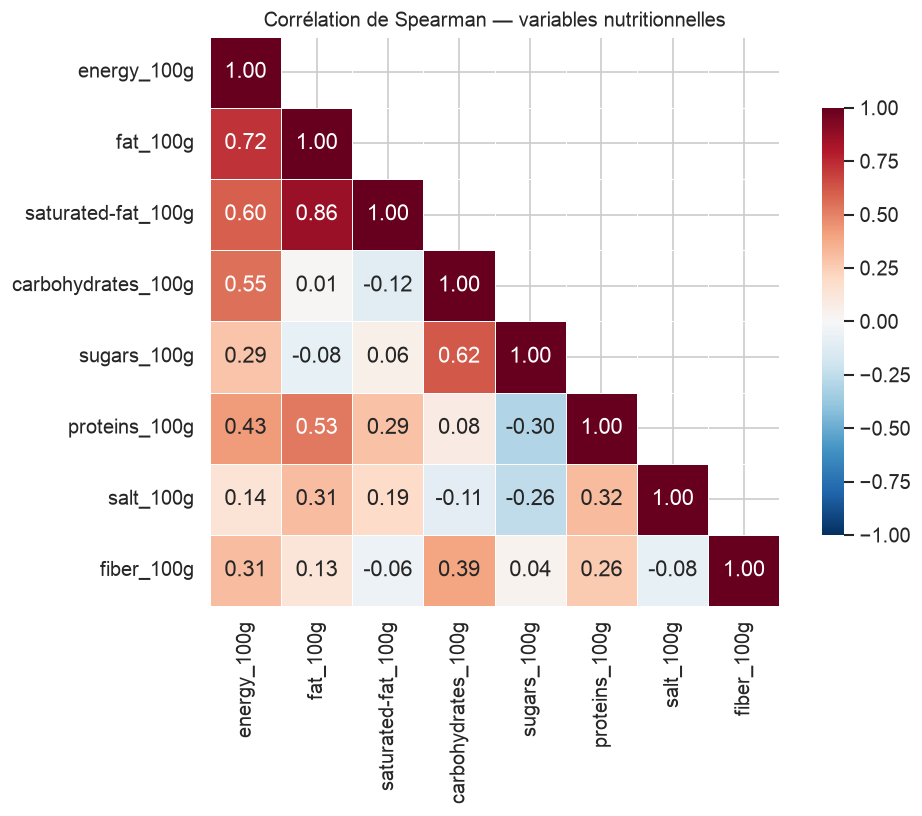

Paires fortement corrélées (|r| > 0.85) :


,var1,var2,spearman_r
17,saturated-fat_100g,fat_100g,0.864551


In [9]:
corr = df[num_features].corr(method='spearman')

# Masque triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=.4,
    ax=ax, cbar_kws={'shrink': .75}
)
ax.set_title('Corrélation de Spearman — variables nutritionnelles', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES + 'correlation_heatmap.png')
plt.show()

# Paires hautement corrélées (|r| > 0.85)
high_corr = (
    corr.where(mask == False)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'spearman_r'})
)
high_corr = high_corr[high_corr['var1'] != high_corr['var2']]
high_corr = high_corr[high_corr['spearman_r'].abs() > 0.85].sort_values('spearman_r', ascending=False)
print('Paires fortement corrélées (|r| > 0.85) :')
display(high_corr)

> **Décision** : on conserve les deux variables de chaque paire redondante pour l'instant
> (les modèles type Random Forest et XGBoost gèrent la multicolinéarité), mais on
> pourra tester de **supprimer `sodium_100g`** (redondant avec `salt_100g`) et
> de réduire `energy_100g` en feature lors de l'ablation study.

## 6. Pouvoir discriminant par classe de Nutri-Score

Boxplots de `energy_100g`, `sugars_100g` et `proteins_100g` selon la classe.
Un bon séparateur linéaire montrera des médianes clairement ordonnées A < B < C < D < E
(ou l'inverse selon la variable).

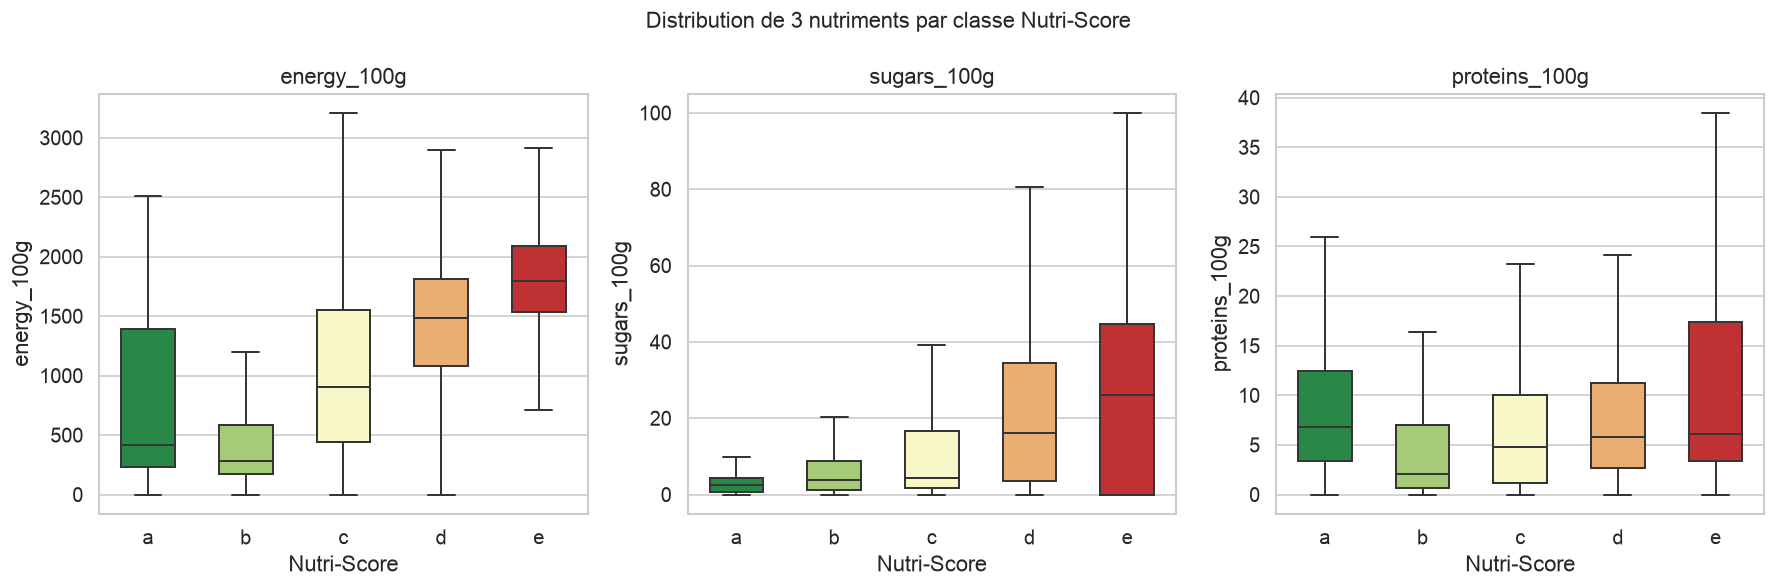

In [10]:
DISCRIMINANT_FEATURES = ['energy_100g', 'sugars_100g', 'proteins_100g']
palette = dict(zip(grade_order, colors))

df_plot = df[df[TARGET].isin(grade_order)].copy()
df_plot[TARGET] = pd.Categorical(df_plot[TARGET], categories=grade_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, DISCRIMINANT_FEATURES):
    lo, hi = PHYSICAL_BOUNDS.get(feat, (0, None))
    data_feat = df_plot[[TARGET, feat]].dropna()
    # enlever les aberrations pour un boxplot lisible
    if hi:
        data_feat = data_feat[(data_feat[feat] >= lo) & (data_feat[feat] <= hi)]

    sns.boxplot(
        data=data_feat, x=TARGET, y=feat,
        palette=palette, order=grade_order,
        showfliers=False, width=0.55, linewidth=1.2,
        ax=ax
    )
    ax.set_title(feat)
    ax.set_xlabel('Nutri-Score')

fig.suptitle('Distribution de 3 nutriments par classe Nutri-Score', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES + 'boxplots_by_grade.png')
plt.show()

> **Observation** :
> - `energy_100g` et `sugars_100g` augmentent clairement de A vers E → fort pouvoir discriminant.
> - `proteins_100g` est plus élevé en A et B → signal plus faible mais réel.
> - La variance intra-classe reste large : un modèle non-linéaire (XGBoost, forêt)
>   captrera mieux les interactions entre nutriments qu'une régression logistique seule.

## 7. Variable catégorielle : `pnns_groups_1`

In [11]:
cat_col = 'pnns_groups_1'
if cat_col in df.columns:
    pnns_counts = df[cat_col].value_counts(dropna=False)
    print(f'Modalités : {pnns_counts.shape[0]}')
    display(pnns_counts.head(20))

    fig, ax = plt.subplots(figsize=(10, 4))
    pnns_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Top-15 catégories PNNS (pnns_groups_1)')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES + 'pnns_groups_distribution.png')
    plt.show()

---
## 8. Synthèse EDA → décisions de preprocessing

### 8.1 Filtrage des lignes

| Critère | Action |
|---|---|
| `nutrition_grade_fr` hors {a,b,c,d,e} ou NaN | **Supprimer** — pas de cible valide |
| Toutes les variables nutritionnelles NaN | **Supprimer** — aucune information |

### 8.2 Traitement des valeurs aberrantes

Appliquer les bornes physiques du tableau §4 via `clip` puis remplacer
les valeurs en dehors par `NaN` :

```python
for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    df[col] = df[col].where(df[col].between(lo, hi))  # hors bornes → NaN
```

### 8.3 Imputation des NaN

- **Variables nutritionnelles** : imputation par la **médiane** de la classe
  (`nutrition_grade_fr`) — plus fidèle que la médiane globale compte tenu du déséquilibre.
- **`pnns_groups_1`** : créer une modalité `'unknown'` pour les NaN.

### 8.4 Variables redondantes

- `sodium_100g` ≈ `salt_100g / 2.54` → **conserver les deux** en baseline,
  tester l'ablation de `sodium_100g` en V2.
- `energy_100g` corrélé à `fat_100g` et `carbohydrates_100g` →
  conserver (information propre sur les calories totales).

### 8.5 Encodage

- `pnns_groups_1` → **OrdinalEncoder** ou **TargetEncoder** selon le modèle.
  Éviter le one-hot si le nombre de modalités est > 15 (trop de colonnes).
- Cible `nutrition_grade_fr` → encoder en entiers 0–4 (a=0, …, e=4).

### 8.6 Gestion du déséquilibre de classes

- Utiliser `class_weight='balanced'` dans sklearn.
- Évaluer avec **F1-macro** et **accuracy balancée**,
  **ne pas** utiliser l'accuracy brute comme métrique principale.

### 8.7 Rappel anti-fuite (non négociable)

> `nutrition-score-fr_100g`, `nutrition-score-uk_100g`, et toute colonne
> contenant `nutriscore` ou `nutrition-score` sont **interdites en feature**.
> Elles sont listées dans `config.BLACKLIST_PATTERNS` et doivent être
> vérifiées dans `preprocessing.py` avant tout `fit`.